## First I repeat the analysis that Alejandro did on the AsmonTV batch

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_json('../data/raw/markiplier_batch_20260608_205250.json')
df.head()

,video_id,text,likes,published_at
0,15mR4-qIbUk,"17:54 Mark: ""you're not even hurting me, it's ...",1376,2026-06-08 16:47:45+00:00
1,15mR4-qIbUk,"Mark, reading is for dorks. I can't believe yo...",1271,2026-06-08 16:27:12+00:00
2,15mR4-qIbUk,"""They lied to me"" The lunged man said as the p...",2821,2026-06-08 16:22:07+00:00
3,15mR4-qIbUk,I think my favorite recurring theme in this pl...,27,2026-06-08 22:16:49+00:00
4,15mR4-qIbUk,“It doesn’t even hurt” Mark says as his batter...,475,2026-06-08 17:54:31+00:00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49898 entries, 0 to 49897
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      49898 non-null  str                
 1   text          49898 non-null  str                
 2   likes         49898 non-null  int64              
 3   published_at  49898 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(1), str(2)
memory usage: 1.5 MB


## Comment Length Analysis

In [4]:
df["word_count"] = (
    df["text"]
    .fillna("")
    .str.split()
    .str.len()
)
df["word_count"].describe(percentiles=[.5,.75,.9,.95,.99,0.999])

count    49898.000000
mean        23.911860
std         27.237897
min          1.000000
50%         18.000000
75%         27.000000
90%         43.000000
95%         60.000000
99%        118.000000
99.9%      296.103000
max       1620.000000
Name: word_count, dtype: float64

I notice that the mean word count is higher than for AsmonTV, although I'm not sure what that means.

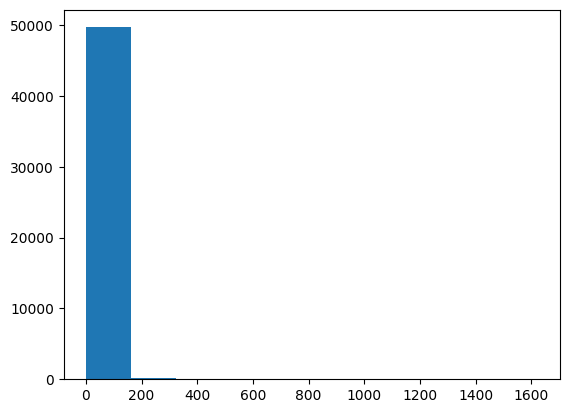

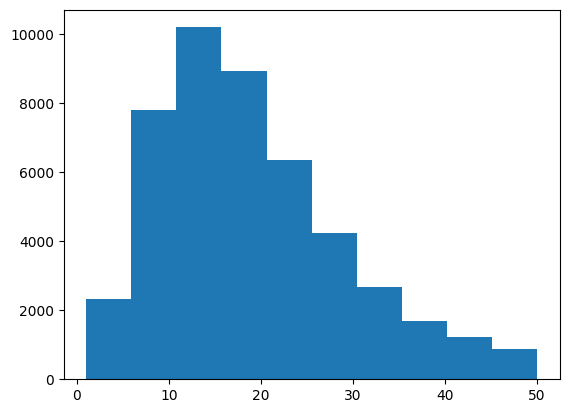

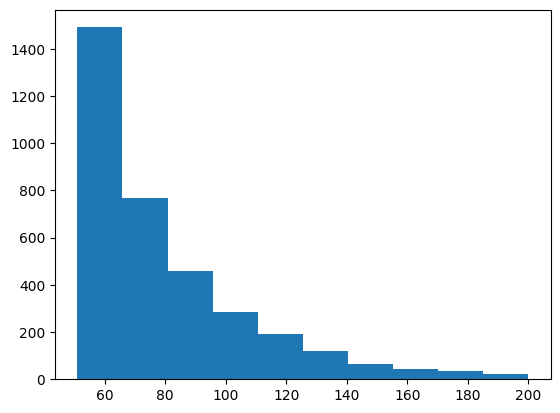

In [5]:
plt.figure()
plt.hist(df['word_count'])

plt.figure()
plt.hist(df.loc[df['word_count']<= 50, 'word_count'])

plt.figure()
plt.hist(df.loc[(df['word_count']> 50) & (df['word_count'] <= 200), 'word_count'])
plt.show()

## Individual Word Analysis
Used a basic tokenizer, matches strings of uninterupted alphanumeric characters

In [6]:
import re

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z0-9]+\b", text)

df['tokens'] = df['text'].apply(tokenize)

In [7]:
df[['text','tokens']].head()

,text,tokens
0,"17:54 Mark: ""you're not even hurting me, it's ...","[17, 54, mark, you, re, not, even, hurting, me..."
1,"Mark, reading is for dorks. I can't believe yo...","[mark, reading, is, for, dorks, i, can, t, bel..."
2,"""They lied to me"" The lunged man said as the p...","[they, lied, to, me, the, lunged, man, said, a..."
3,I think my favorite recurring theme in this pl...,"[i, think, my, favorite, recurring, theme, in,..."
4,“It doesn’t even hurt” Mark says as his batter...,"[it, doesn, t, even, hurt, mark, says, as, his..."


In [8]:
from collections import Counter

counter = Counter()
for tokens in df['tokens']:
    counter.update(tokens)
print("Unique words: ", len(counter))
counter.most_common(10)

Unique words:  29534


[('the', 58228),
 ('i', 31465),
 ('to', 28486),
 ('a', 25455),
 ('and', 24682),
 ('mark', 22496),
 ('it', 19571),
 ('of', 19257),
 ('is', 19007),
 ('that', 16666)]

The number of unique words is around the same as for AsmonTV, which should be expected.

In [9]:
import random
singletons = {
    word
    for word, count in counter.items()
    if count == 1
}

print('Number of singletons: ',len(singletons))
print('Percentage of total words: ',len(singletons) / len(counter))
print('Examples:')
random.seed(2)
random.sample(list(singletons), 10)

Number of singletons:  12839
Percentage of total words:  0.43471930656192864
Examples:


['comin',
 'scarafaggi',
 'arbitrary',
 'invading',
 'conciously',
 'rember',
 'moistcritical',
 'shamadoo',
 'hogge',
 'weeeery']

In [10]:
artifact_words = {
    "don",
    "doesn",
    "didn",
    "isn",
    "aren",
    "wasn",
    "weren",
    "won",
    "wouldn",
    "couldn",
    "shouldn",
    "ve",
    "ll",
    "re",
    "nt",
    "m"
}

artifact_df = pd.DataFrame(
    [
        (word, counter[word])
        for word in artifact_words
    ],
    columns=["token", "frequency"]
)

artifact_df = artifact_df.sort_values(
    "frequency",
    ascending=False
).reset_index(drop=True)

display(artifact_df)

,token,frequency
0,m,3745
1,ve,2333
2,don,2179
3,re,2150
4,didn,1175
5,doesn,962
6,ll,862
7,isn,485
8,wasn,360
9,won,275


## Time Span Analysis

In [11]:
print('Earliest date: ',df['published_at'].min())
print('Latest date: ',df['published_at'].max())
print('Time span: ', df['published_at'].max()-df['published_at'].min())

Earliest date:  2022-10-26 23:00:29+00:00
Latest date:  2026-06-09 00:50:43+00:00
Time span:  1321 days 01:50:14


It looks like Markiplier was pulled from a longer span of time than AsmonTV.

Daily Comment Statistics
Mean:     38.00
Median:   27.00
Min:      1
Max:      174
Std Dev:  34.42


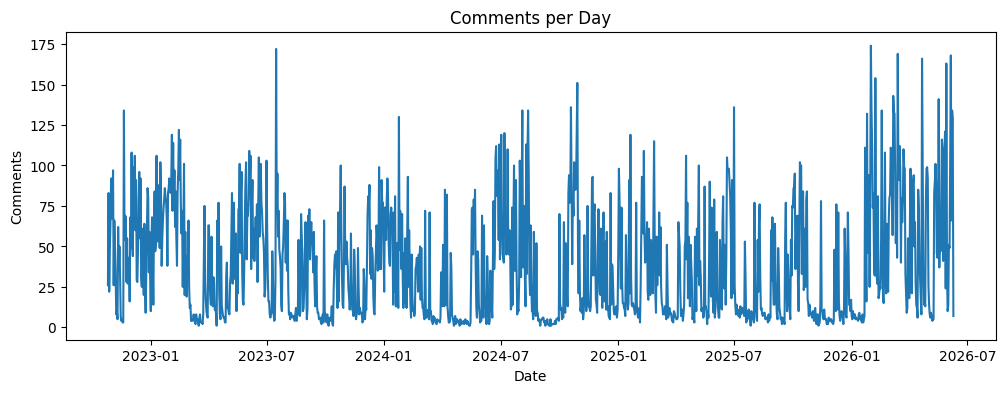

In [12]:
daily_counts = (
    df.groupby(df["published_at"].dt.date)
      .size()
)

print("Daily Comment Statistics")
print(f"Mean:     {daily_counts.mean():.2f}")
print(f"Median:   {daily_counts.median():.2f}")
print(f"Min:      {daily_counts.min()}")
print(f"Max:      {daily_counts.max()}")
print(f"Std Dev:  {daily_counts.std():.2f}")

plt.figure(figsize=(12, 4))
daily_counts.plot()

plt.title("Comments per Day")
plt.ylabel("Comments")
plt.xlabel("Date")

plt.show()

The mean comments per day is much lower, although I wonder how much of that comes down to how many videos we scraped.

Weekly Comment Statistics
Mean:     262.62
Median:   239.50
Min:      11
Max:      730
Std Dev:  167.56


C:\Users\Jamie\AppData\Local\Temp\ipykernel_19992\1121114334.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["published_at"].dt.to_period("W"))


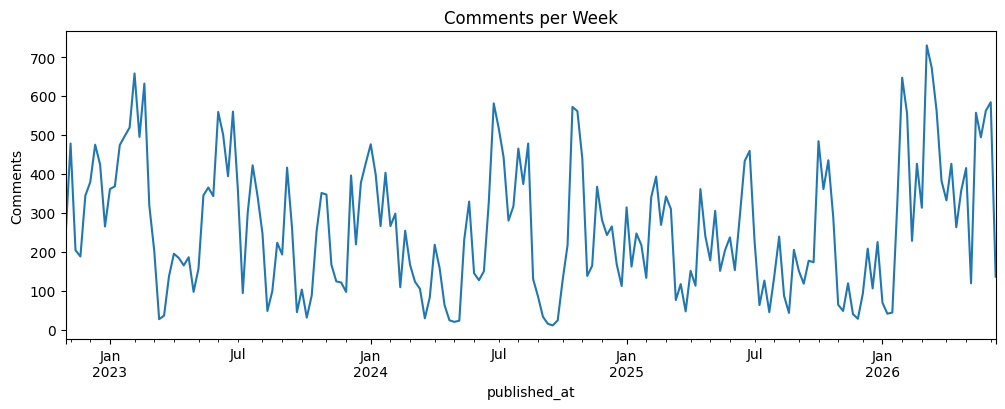

In [13]:
weekly_counts = (
    df.groupby(df["published_at"].dt.to_period("W"))
      .size()
)

print("Weekly Comment Statistics")
print(f"Mean:     {weekly_counts.mean():.2f}")
print(f"Median:   {weekly_counts.median():.2f}")
print(f"Min:      {weekly_counts.min()}")
print(f"Max:      {weekly_counts.max()}")
print(f"Std Dev:  {weekly_counts.std():.2f}")


weekly_counts.plot(figsize=(12,4))
plt.title("Comments per Week")
plt.ylabel("Comments")
plt.show()

## Number of Videos

In [14]:
len(pd.unique(df["video_id"]))

499

Comments per video

In [15]:
len(df)/len(pd.unique(df["video_id"]))

99.99599198396794

In [16]:
from sklearn.model_selection import TimeSeriesSplit

Here I am running an example of a word at a particular time (whatever time comment 10000 was published at).

In [17]:
df.published_at[1000]

Timestamp('2026-05-25 18:01:54+0000', tz='UTC')

In [18]:
import datetime as dt

In [19]:
dfcopy = df.copy()

The cell below takes a significant amount of time to run (my stopwatch says 13 seconds)

In [20]:
# The cell below this does the same job much faster, do not run this
#for i in range(0,len(df)):
#    today=df.published_at[10000]
#    if df.published_at[i]>today+dt.timedelta(days=7):
#        dfcopy.loc[i,'time_group']='future'
#    elif df.published_at[i]>today:
#        dfcopy.loc[i,'time_group']='next_week'
#    elif df.published_at[i]>today-dt.timedelta(days=1):
#        dfcopy.loc[i,'time_group']='last_day'
#    elif df.published_at[i]>today-dt.timedelta(days=7):
#        dfcopy.loc[i,'time_group']='last_week'
#    elif df.published_at[i]>today-dt.timedelta(days=30):
#        dfcopy.loc[i,'time_group']='last_month'
#    else:
#        dfcopy.loc[i,'time_group']='past'

In [21]:
# This runs so much faster than the previous cell
today=df.published_at[1000]
# I wanted to use dt.datetime.min and max below, but that causes an overflow error https://stackoverflow.com/questions/55618951/pandas-pd-cut-on-timestamps-valueerror-bins-must-increase-monotonically
dfcopy['time_group'] = pd.cut(df.published_at,bins = [today-dt.timedelta(days = 10000),today-dt.timedelta(days=30),today-dt.timedelta(days=7),today-dt.timedelta(days=1),today,today+dt.timedelta(days=7),today+dt.timedelta(days = 10000)],
       labels = ['past','last_month','last_week','last_day','next_week','future'])

In [22]:
dfcopy.time_group.value_counts()

time_group
past          47014
last_month     1137
future          711
next_week       509
last_week       461
last_day         66
Name: count, dtype: int64

In [23]:
timegroups = dfcopy.groupby('time_group')

In [24]:
# This cell takes ~1 second to run. The cell below is faster
#for timeframe in timegroups.groups.keys():
#    comments_with_word=0
#    for i in dfcopy.groupby('time_group').groups[timeframe]:
#        if 'undertale' in dfcopy.tokens.iloc[i]:
#            comments_with_word = comments_with_word + 1
#    print("relative frequency of words in "+timeframe)
#    print(comments_with_word/dfcopy.time_group.value_counts()[timeframe])

In [25]:
for timeframe in timegroups.groups.keys():
    print("relative frequency of words in "+timeframe)
    print(dfcopy.loc[timegroups.groups[timeframe]].tokens.map(lambda x: 'kirk' in x).sum() #This counts how many comments
          /timegroups.size()[timeframe])

relative frequency of words in past
0.0
relative frequency of words in last_month
0.0
relative frequency of words in last_week
0.0
relative frequency of words in last_day
0.0
relative frequency of words in next_week
0.0
relative frequency of words in future
0.0


In [26]:
dfcopy.loc[dfcopy.groupby('time_group').groups['future']]

,video_id,text,likes,published_at,word_count,tokens,time_group
0,15mR4-qIbUk,"17:54 Mark: ""you're not even hurting me, it's ...",1376,2026-06-08 16:47:45+00:00,22,"[17, 54, mark, you, re, not, even, hurting, me...",future
1,15mR4-qIbUk,"Mark, reading is for dorks. I can't believe yo...",1271,2026-06-08 16:27:12+00:00,28,"[mark, reading, is, for, dorks, i, can, t, bel...",future
2,15mR4-qIbUk,"""They lied to me"" The lunged man said as the p...",2821,2026-06-08 16:22:07+00:00,16,"[they, lied, to, me, the, lunged, man, said, a...",future
3,15mR4-qIbUk,I think my favorite recurring theme in this pl...,27,2026-06-08 22:16:49+00:00,22,"[i, think, my, favorite, recurring, theme, in,...",future
4,15mR4-qIbUk,“It doesn’t even hurt” Mark says as his batter...,475,2026-06-08 17:54:31+00:00,14,"[it, doesn, t, even, hurt, mark, says, as, his...",future
...,...,...,...,...,...,...,...
46936,-x4OkAaaCaU,38:24 i think you’re thinking of the Dark Troo...,0,2026-06-08 14:32:11+00:00,12,"[38, 24, i, think, you, re, thinking, of, the,...",future
48395,MISAiE64vD0,Me coming back and rewatching because it’s a g...,0,2026-06-08 19:26:24+00:00,39,"[me, coming, back, and, rewatching, because, i...",future
49386,7GbDedt1nkw,"I wonder if ""increased firepower"" translates t...",0,2026-06-07 21:42:25+00:00,34,"[i, wonder, if, increased, firepower, translat...",future
49387,7GbDedt1nkw,"11:35 - Mark: ""You don't need to worry about m...",0,2026-06-05 12:17:50+00:00,37,"[11, 35, mark, you, don, t, need, to, worry, a...",future


In [27]:
dfcopy.loc[dfcopy.groupby('time_group').groups['future']].tokens.map(lambda x: 'undertale' in x).sum()

np.int64(0)

In [28]:
timegroups.groups

{'past': [2601, 2602, 2603, 2604, 2605, 2606, 2608, 2609, 2610, 2611, 2612, 2613, 2614, 2615, 2616, 2617, 2618, 2620, 2621, 2622, 2624, 2625, 2626, 2628, 2629, 2630, 2632, 2633, 2634, 2635, 2636, 2637, 2638, 2639, 2640, 2641, 2642, 2644, 2645, 2646, 2647, 2648, 2649, 2650, 2652, 2653, 2654, 2655, 2656, 2657, 2658, 2660, 2661, 2662, 2664, 2665, 2666, 2668, 2669, 2670, 2672, 2673, 2674, 2676, 2677, 2678, 2679, 2680, 2681, 2682, 2683, 2684, 2685, 2687, 2688, 2689, 2690, 2691, 2692, 2693, 2695, 2696, 2697, 2699, 2700, 2701, 2702, 2703, 2704, 2705, 2706, 2707, 2708, 2709, 2710, 2711, 2712, 2713, 2714, 2715, ...], 'last_month': [1501, 1502, 1503, 1505, 1506, 1507, 1509, 1511, 1513, 1514, 1515, 1517, 1518, 1519, 1521, 1522, 1523, 1525, 1526, 1527, 1529, 1530, 1531, 1533, 1534, 1535, 1537, 1538, 1539, 1541, 1542, 1543, 1545, 1546, 1547, 1549, 1550, 1551, 1553, 1554, 1555, 1557, 1558, 1559, 1561, 1562, 1563, 1565, 1566, 1567, 1569, 1570, 1571, 1573, 1574, 1575, 1577, 1578, 1579, 1581, 1582, 158

In [29]:
words = set({})

Code below takes a while to run

In [30]:
for i in range(0,len(dfcopy)):
    words=words.union(set(dfcopy.tokens[i]))

Number of unique words.

In [31]:
len(words)

29534

In [32]:
dfwords = pd.DataFrame(words, columns = ['word'])

In [33]:
dfwords['current_time'] = df.published_at[10000]

In [34]:
dfwords

,word,current_time
0,greaaaat,2025-10-03 22:18:01+00:00
1,ducts,2025-10-03 22:18:01+00:00
2,vomitting,2025-10-03 22:18:01+00:00
3,figurine,2025-10-03 22:18:01+00:00
4,foreshadowing,2025-10-03 22:18:01+00:00
...,...,...
29529,bewilderment,2025-10-03 22:18:01+00:00
29530,metacritic,2025-10-03 22:18:01+00:00
29531,doinnngg,2025-10-03 22:18:01+00:00
29532,restockers,2025-10-03 22:18:01+00:00


In [35]:
def TimeGrouper(dfcomment,date):
    # I wanted to use dt.datetime.min and max below, but that causes an overflow error https://stackoverflow.com/questions/55618951/pandas-pd-cut-on-timestamps-valueerror-bins-must-increase-monotonically
    dfcomment['time_group'] = pd.cut(dfcomment.published_at,bins = [date-dt.timedelta(days = 10000),date-dt.timedelta(days=30),date-dt.timedelta(days=7),date-dt.timedelta(days=1),date,date+dt.timedelta(days=7),date+dt.timedelta(days = 10000)],
           labels = ['past','last_month','last_week','last_day','next_week','future'])

In [36]:
def RelativeFrequency(dfcomment, word):
    RelFreqList = []
    timegroups = dfcomment.groupby('time_group')
    for timeframe in timegroups.groups.keys():
        RelFreqList += [dfcomment.loc[timegroups.groups[timeframe]].tokens.map(lambda x: word in x).sum() #This counts how many comments have this word in them
              /timegroups.size()[timeframe]]
    return RelFreqList

In [42]:
TimeGrouper(dfcopy,df.published_at[10000])

The code below took 787 seconds (a little over 13 minutes) to run

In [64]:
TimeGrouper(dfcopy,df.published_at[10000])
dfwords[['rel_freq_past','rel_freq_last_month','rel_freq_last_week','rel_freq_last_day','rel_freq_next_week','rel_freq_future']] = pd.DataFrame(dfwords.word.map(lambda word: RelativeFrequency(dfcopy,word)).to_list())

In [67]:
dfwords.describe()

,rel_freq_past,rel_freq_last_month,rel_freq_last_week,rel_freq_last_day,rel_freq_next_week,rel_freq_future
count,29534.000000,29534.000000,29534.000000,29534.000000,29534.000000,29534.000000
mean,0.000721,0.000628,0.000658,0.000682,0.000780,0.000694
std,0.008494,0.007675,0.007795,0.008513,0.009216,0.007901
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000027,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000027,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000133,0.000000,0.000000,0.000000,0.000000,0.000181
max,0.588904,0.550107,0.521875,0.626374,0.620178,0.549027


In [68]:
dfwords.to_csv("MarkiplierEDAExample.csv")

,word,current_time,rel_freq_past,rel_freq_last_month,rel_freq_last_week,rel_freq_last_day,rel_freq_next_week,rel_freq_future
0,greaaaat,2025-10-03 22:18:01+00:00,0.000000,0.0,0.0,0.0,0.000000,0.000091
1,ducts,2025-10-03 22:18:01+00:00,0.000080,0.0,0.0,0.0,0.000000,0.000000
2,vomitting,2025-10-03 22:18:01+00:00,0.000027,0.0,0.0,0.0,0.000000,0.000000
3,figurine,2025-10-03 22:18:01+00:00,0.000027,0.0,0.0,0.0,0.000000,0.000000
4,foreshadowing,2025-10-03 22:18:01+00:00,0.000797,0.0,0.0,0.0,0.002967,0.001177
5,ragnarok,2025-10-03 22:18:01+00:00,0.000027,0.0,0.0,0.0,0.000000,0.000000
6,bouncy,2025-10-03 22:18:01+00:00,0.000053,0.0,0.0,0.0,0.000000,0.000000
7,unbroken,2025-10-03 22:18:01+00:00,0.000027,0.0,0.0,0.0,0.000000,0.000000
8,coat,2025-10-03 22:18:01+00:00,0.000239,0.0,0.0,0.0,0.000000,0.000453
9,fumperdink,2025-10-03 22:18:01+00:00,0.000638,0.0,0.0,0.0,0.000000,0.000000
